### BASIC FITTING

**CURRENTLY**, the fitting module is still under development. There are still some rough edges in the API before proceeding with the creation of the optimization engine. However, for personal preference, I have started some preliminary work. Currently, only one optimizer is available, an instance of the Nelder-Mead algorithm. 

The ultimate goal, however, is not to reimplement complex optimizers (that would be like reinventing the wheel) but to make the API fully compatible with existing frameworks such as Scipy, MCMC, and others. Therefore, consider this tutorial more as a logic exercise than anything else.


### Single model fitting

 34%|███▍      | 342/1000 [00:00<00:00, 11046.57it/s]

Treshold raggiunta
Optimizee Params ['mu', 'sigma', 'A']: [11.02886177  6.48501832  1.53827886]


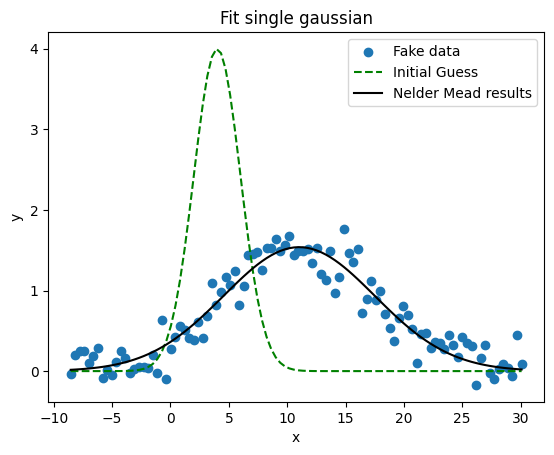

In [1]:
from zoo import Fittable1D
from optimizers import NelderMead
import numpy as np
import matplotlib.pyplot as plt

#create our simple model
class Gaussian1D(Fittable1D):
    @staticmethod
    def evaluate(x, mu, sigma, A):
        return A * np.exp(-((x - mu) ** 2) / (2 * sigma**2))


gaus = Gaussian1D()


# Generate fake data
def generate_fake_data(mu, sigma, A, num_points=100, noise_level=0.2):
    x = np.linspace(mu - 3 * sigma, mu + 3 * sigma, num_points)
    y_true = Gaussian1D.evaluate(x, mu, sigma, A)
    noise = noise_level * np.random.randn(num_points)
    y_noisy = y_true + noise
    return x, y_noisy


# True params
true_mu = 10.77
true_sigma = 6.44
true_A = 1.5

# G
x_data, y_data = generate_fake_data(true_mu, true_sigma, true_A)

# Initial guess
initial_guess = [3.6, 1.5, 0.6]  # [mu, sigma, A]

# or equivalently... a dictionary is supported
initial_guess = {"mu": 4, "A": 4, "sigma": 2}

optimizer = NelderMead(model=gaus, treshold=1e-6, delta=0.1)


results = optimizer.minimize(
    x0=initial_guess, grid=[x_data], data=[y_data], progress=True, maxiter=1000
)



print(f"Optimizee Params {gaus.parameters_names}:", results)


# Grafico dei dati originali e della curva ottimizzata
plt.scatter(x_data, y_data, label="Fake data")

plt.plot(
    x_data,
    gaus([x_data], initial_guess),
    color="green",
    linestyle="--",
    label="Initial Guess",
)

plt.plot(x_data, gaus([x_data], results), c="black", label="Nelder Mead results")

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fit single gaussian")
plt.show()

## COMPOSITE MODEL FITTING

####  WITH FROZEN PARAMETERS

Try now to fit a composite model derived from a previous example

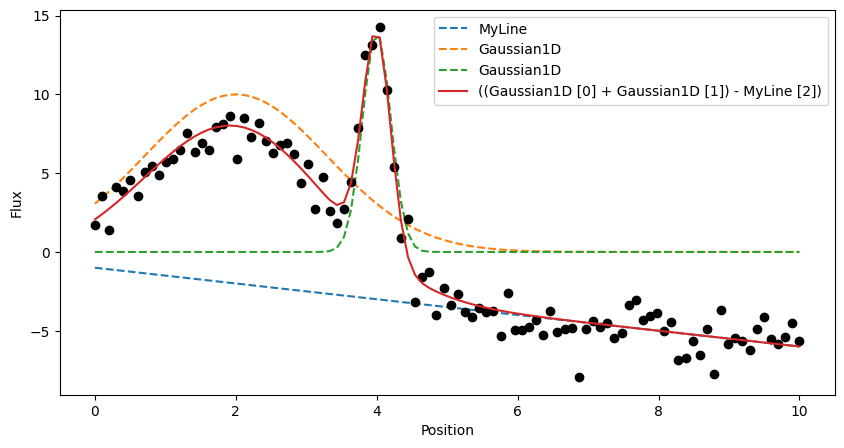

In [2]:
from zoo import Fittable1D
import numpy as np

# defining our simple models
X = np.linspace(0, 10, 100)


class Gaussian1D(Fittable1D):
    @staticmethod
    def evaluate(x, amp, x0, stddev):
        return amp * np.exp(-0.5 * (x - x0) ** 2 / stddev**2)


class Line1D(Fittable1D):
    @staticmethod
    def evaluate(x, a, b):
        return a * x + b


# NOTE I'll add values for some parameter
gaussian = Gaussian1D(name="MyGaussian", amp=10, x0=5)

line = Line1D(name="MyLine", a=0.5)
g1 = Gaussian1D(amp=10, x0=2, stddev=1.3)
g2 = Gaussian1D(amp=14, x0=4, stddev=0.2)


# random composite model
g1_g2 = (g1 + g2) - line


y = g1_g2([X]) + np.random.normal(0.0, 1, X.shape)

# Plot the data with the best-fit model
plt.figure(figsize=(10, 5))
plt.plot(X, -line([X]), linestyle="--", label=line.name)
plt.plot(X, g1([X]), linestyle="--", label=g1.name)
plt.plot(X, g2([X]), linestyle="--", label=g2.name)
plt.plot(X, y, "ko")
plt.plot(X, g1_g2([X]), label=g1_g2.composite_structure())
plt.legend()
plt.xlabel("Position")
plt.ylabel("Flux")
plt.show()

In [3]:
print(g1_g2)

COMPOSITE MODEL NAME: CompositeModel 
CONTAINED MODELS: ['Gaussian1D', 'Gaussian1D', 'MyLine']
GRID VARIABLES: ['x']
LOGIC: ((Gaussian1D [0] + Gaussian1D [1]) - MyLine [2])
FREE PARAMS: 8
______________________________________________________________________
     NOME            VALORE     FREEZE     BOUNDS               
______________________________________________________________________
0    amp_0           10.00      0          (-inf, inf)         
1    x0_0            2.00       0          (-inf, inf)         
2    stddev_0        1.30       0          (-inf, inf)         
3    amp_1           14.00      0          (-inf, inf)         
4    x0_1            4.00       0          (-inf, inf)         
5    stddev_1        0.20       0          (-inf, inf)         
6    a_2             0.50       0          (-inf, inf)         
7    b_2             1.00       0          (-inf, inf)         



 19%|█▉        | 1879/10000 [00:00<00:01, 6428.25it/s]


Treshold raggiunta
Optimizee Params ['amp_0', 'x0_0', 'stddev_0', 'amp_1', 'x0_1', 'stddev_1', 'a_2', 'b_2']: [11.34621067  1.91882396  1.49798197 14.20449851  0.23791041  3.21302638]


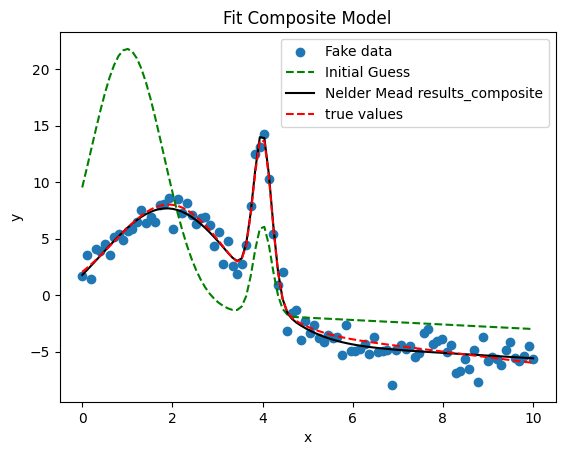

In [4]:
# we freeze the peack to show how fitting is executed with frozen parameters
g1_g2.freeze_parameters("stddev_1", "x0_1")

# or equivalently... a dictionary is supported
initial_guess = {
    "amp_0": 23,
    "x0_0": 1,
    "stddev_0": 0.8,
    "amp_1": 8,
    #'x0_1':2,
    #'stddev_1':1,
    "a_2": 0.2,
    "b_2": 1,
}

optimizer = NelderMead(model=g1_g2, treshold=1e-6, delta=0.1)


results_composite = optimizer.minimize(
    x0=initial_guess, grid=[X], data=[y], progress=True, maxiter=10000
)


print(f"Optimizee Params {g1_g2.parameters_names}:", results_composite)


# Grafico dei dati originali e della curva ottimizzata
plt.scatter(X, y, label="Fake data")

plt.plot(
    X,
    g1_g2([X], initial_guess),
    color="green",
    linestyle="--",
    label="Initial Guess",
)

plt.plot(
    X, g1_g2([X], results_composite), c="black", label="Nelder Mead results_composite"
)

plt.plot(X, g1_g2([X]), c='red',linestyle='--',label='true values')

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fit Composite Model")
plt.show()